In [ ]:

import os



# 🗂️ Define the path to your zip file in Google Drive
zip_path = '/content/drive/MyDrive/TIF DATA-20250625T080650Z-1-001.zip'

# 📁 Directory to extract the files into
extract_dir = '/content/unzipped_output'
os.makedirs(extract_dir, exist_ok=True)

# 🧩 Unzip the file
!unzip -q "{zip_path}" -d "{extract_dir}"

print(f"✅ Files extracted to: {extract_dir}")


✅ Files extracted to: /content/unzipped_output


In [ ]:
import os

def print_directory_tree(root_dir, indent=""):
    for item in sorted(os.listdir(root_dir)):
        item_path = os.path.join(root_dir, item)
        if os.path.isdir(item_path):
            print(f"{indent}📁 {item}/")
            print_directory_tree(item_path, indent + "    ")
        else:
            print(f"{indent}📄 {item}")

# 📂 Set the root folder path
folder_path = "/content/unzipped_output"  # Replace with your target folder

# 🖨️ Print the directory structure
print(f"Directory structure of: {folder_path}\n")
print_directory_tree(folder_path)


Directory structure of: /content/unzipped_output

📁 .TIF DATA/
    📄 DEM_BASED_COREGISTERED_IMAGE.dim
    📄 DEM_BASED_COREGISTERED_IMAGE.tif
    📄 REFERENCE_IMAGE.dim
    📄 REFERENCE_IMAGEl.tif
    📄 SECONDARY_IMAGE.dim
    📄 SECONDARY_IMAGE.tif


In [ ]:
!pip install albumentations==1.3.1 --quiet
!pip install opencv-python-headless --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
pip install rasterio pillow numpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 79.8 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
from torchvision import transforms
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import random
import rasterio

In [ ]:
# 1. ✅ Install Required Packages
!pip install rasterio --quiet

import os, numpy as np, torch
import matplotlib.pyplot as plt
import rasterio
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from datetime import datetime
from tqdm import tqdm

# 2. ✅ Config
PATCH_SIZE = 100
STRIDE = 50
SHIFT_RANGE = 2
NUM_CLASSES = (2 * SHIFT_RANGE + 1) ** 2
BATCH_SIZE = 16
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Metadata constants (from your .dim values)
PIXEL_SPACING = 10  # meters
DATE_FORMAT = "%d-%b-%Y %H:%M:%S.%f"
T_REF = datetime.strptime("09-OCT-2024 12:48:33.562040", DATE_FORMAT)
T_SEC = datetime.strptime("21-OCT-2024 12:48:33.224671", DATE_FORMAT)
DELTA_DAYS = (T_SEC - T_REF).days  # Should be 12
print(f"✅ ΔT = {DELTA_DAYS} days, pixel spacing = {PIXEL_SPACING} m")


✅ ΔT = 11 days, pixel spacing = 10 m


In [ ]:
# 3. ✅ Load SAR Images
def load_tif(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32)

ref_path = '/content/unzipped_output/.TIF DATA/REFERENCE_IMAGEl.tif' # Corrected filename
sec_path = '/content/unzipped_output/.TIF DATA/SECONDARY_IMAGE.tif'  # better than raw secondary

reference_img = load_tif(ref_path)
secondary_img = load_tif(sec_path)
H, W = reference_img.shape
print("📐 Image shape:", H, "×", W)

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


📐 Image shape: 3243 × 2731


In [ ]:
# 4. ✅ Normalize Patch
def normalize(patch):
    std = np.std(patch)
    return np.zeros_like(patch) if std < 1e-6 else (patch - np.mean(patch)) / (std + 1e-5)

# 5. ✅ Patch Coordinates
coords = [(x, y) for y in range(0, H - PATCH_SIZE + 1, STRIDE)
                for x in range(0, W - PATCH_SIZE + 1, STRIDE)]

# 6. ✅ Dataset Class
class GlacierDataset(Dataset):
    def __init__(self, ref_img, sec_img, coords):
        self.ref = ref_img
        self.sec = sec_img
        self.coords = coords
        self.sec_h, self.sec_w = sec_img.shape

    def __len__(self):
        return len(self.coords) * NUM_CLASSES

    def __getitem__(self, idx):
        patch_idx = idx // NUM_CLASSES
        shift_idx = idx % NUM_CLASSES

        x, y = self.coords[patch_idx]
        dx = (shift_idx % (2 * SHIFT_RANGE + 1)) - SHIFT_RANGE
        dy = (shift_idx // (2 * SHIFT_RANGE + 1)) - SHIFT_RANGE

        ref_patch = normalize(self.ref[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
        x_shift, y_shift = x + dx * STRIDE, y + dy * STRIDE

        if 0 <= x_shift <= self.sec_w - PATCH_SIZE and 0 <= y_shift <= self.sec_h - PATCH_SIZE:
            sec_patch = normalize(self.sec[y_shift:y_shift+PATCH_SIZE, x_shift:x_shift+PATCH_SIZE])
        else:
            sec_patch = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

        inp = np.stack([ref_patch, sec_patch], axis=0)
        label = (dy + SHIFT_RANGE) * (2 * SHIFT_RANGE + 1) + (dx + SHIFT_RANGE)
        return torch.tensor(inp, dtype=torch.float32), label

dataset = GlacierDataset(reference_img, secondary_img, coords)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
print(f"✅ Total reference patches: {len(coords)} | Total training samples: {len(dataset)}")


✅ Total reference patches: 3339 | Total training samples: 83475


In [ ]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(2, 96, kernel_size=11, stride=4, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        # Dynamically compute flattened dimension
        with torch.no_grad():
            dummy = torch.zeros(1, 2, PATCH_SIZE, PATCH_SIZE)
            feat = self.features(dummy)
            self.flat_dim = feat.view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(self.flat_dim, 4096), nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [ ]:
# 8. ✅ Train Model
model = AlexNet().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, targets in tqdm(loader, desc=f"Epoch {epoch+1:02d}"):
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == targets).sum().item()
        total += targets.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1:02d}, Loss: {total_loss:.4f}, Accuracy: {acc:.2f}%")


Epoch 01: 100%|██████████| 5218/5218 [01:45<00:00, 49.44it/s]


Epoch 01, Loss: 16105.2353, Accuracy: 8.45%


Epoch 02: 100%|██████████| 5218/5218 [01:43<00:00, 50.58it/s]


Epoch 02, Loss: 15083.8415, Accuracy: 15.25%


Epoch 03: 100%|██████████| 5218/5218 [01:44<00:00, 49.75it/s]


...

Epoch 98, Loss: 1609.3380, Accuracy: 90.10%


Epoch 99: 100%|██████████| 5218/5218 [01:42<00:00, 51.11it/s]


Epoch 99, Loss: 1641.6127, Accuracy: 89.85%


Epoch 100: 100%|██████████| 5218/5218 [01:43<00:00, 50.24it/s]

Epoch 100, Loss: 1580.9140, Accuracy: 90.18%


In [ ]:
# Save model state_dict
model_path = "/content/drive/MyDrive/glacier_displacement_model.pth"
torch.save(model.state_dict(), model_path)

print(f"✅ Model saved to: {model_path}")


✅ Model saved to: /content/drive/MyDrive/glacier_displacement_model.pth


In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

model.eval()
displacements = []
positions = []

with torch.no_grad():
    for (x, y) in tqdm(coords, desc="🔍 Inference"):
        ref_patch = reference_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        ref_patch = normalize(ref_patch)

        input_batch = []

        # Prepare 25 candidates (5x5 shifts)
        for dy in range(-SHIFT_RANGE, SHIFT_RANGE + 1):
            for dx in range(-SHIFT_RANGE, SHIFT_RANGE + 1):
                x_shift = x + dx * STRIDE
                y_shift = y + dy * STRIDE

                if (0 <= x_shift <= secondary_img.shape[1] - PATCH_SIZE and
                    0 <= y_shift <= secondary_img.shape[0] - PATCH_SIZE):
                    sec_patch = secondary_img[y_shift:y_shift+PATCH_SIZE, x_shift:x_shift+PATCH_SIZE]
                    sec_patch = normalize(sec_patch)
                else:
                    sec_patch = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

                stacked = np.stack([ref_patch, sec_patch], axis=0)
                input_batch.append(stacked)

        input_batch = torch.tensor(np.stack(input_batch), dtype=torch.float32).to(DEVICE)
        outputs = model(input_batch)
        probs = torch.softmax(outputs, dim=1)

        # Class with max probability for each patch
        best_idx = torch.argmax(probs[:, :], dim=1)
        shift_class = torch.argmax(torch.bincount(best_idx)).item()

        dx = (shift_class % (2 * SHIFT_RANGE + 1)) - SHIFT_RANGE
        dy = (shift_class // (2 * SHIFT_RANGE + 1)) - SHIFT_RANGE

        displacements.append((dx, dy))
        positions.append((x, y))

positions = np.array(positions)
displacements = np.array(displacements)


🔍 Inference: 100%|██████████| 3339/3339 [00:25<00:00, 133.45it/s]


In [ ]:
# Convert displacement to meters/day
pixel_spacing = 10  # meters
delta_days = 12

displacements_m = displacements * pixel_spacing
velocity = displacements_m / delta_days  # shape: [N, 2]

# Magnitude of velocity vector
magnitude = np.linalg.norm(velocity, axis=1)


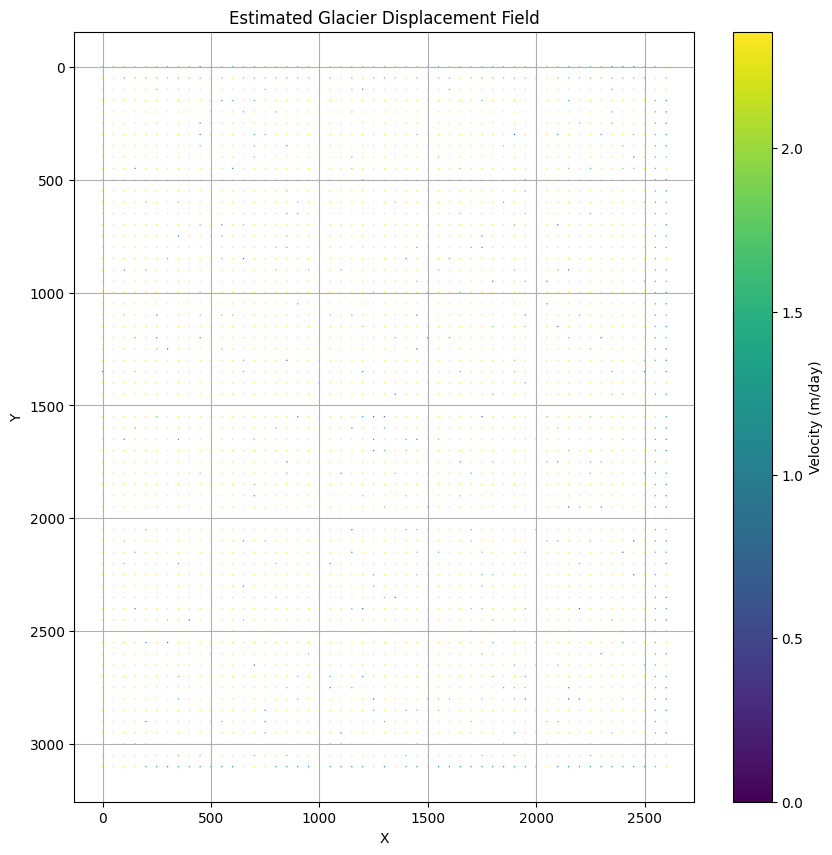

In [ ]:
# Quiver Plot
plt.figure(figsize=(10, 10))
plt.quiver(positions[:, 0], positions[:, 1],
           velocity[:, 0], -velocity[:, 1],
           magnitude, angles='xy', scale_units='xy', scale=1, cmap='viridis')
plt.colorbar(label='Velocity (m/day)')
plt.title('Estimated Glacier Displacement Field')
plt.xlabel('X')
plt.ylabel('Y')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

df = pd.DataFrame({
    'x': positions[:, 0],
    'y': positions[:, 1],
    'dx_m': velocity[:, 0],
    'dy_m': velocity[:, 1],
    'speed_m_per_day': magnitude
})

csv_path = '/content/glacier_outputs/displacement_vectors.csv'
os.makedirs(os.path.dirname(csv_path), exist_ok=True)
df.to_csv(csv_path, index=False)
print(f"✅ Displacement CSV saved to: {csv_path}")


✅ Displacement CSV saved to: /content/glacier_outputs/displacement_vectors.csv


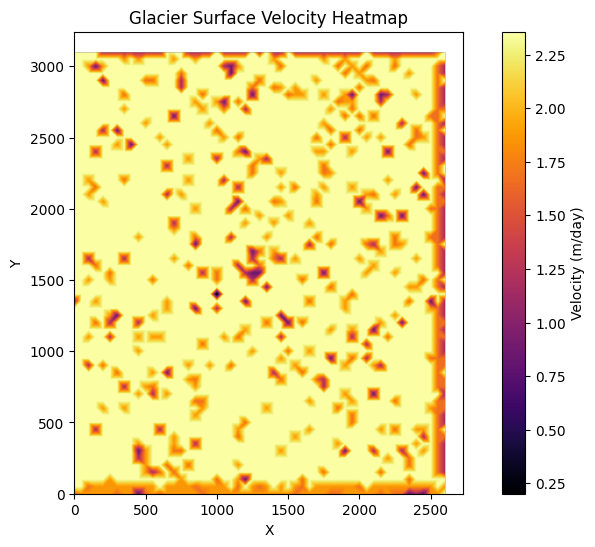

In [ ]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Interpolation for heatmap
grid_x, grid_y = np.mgrid[
    0:reference_img.shape[1]:500j,
    0:reference_img.shape[0]:500j
]
grid_magnitude = griddata(positions, magnitude, (grid_x, grid_y), method='linear')

plt.figure(figsize=(10, 6))
plt.imshow(grid_magnitude.T, origin='lower', cmap='inferno', extent=(0, reference_img.shape[1], 0, reference_img.shape[0]))
plt.colorbar(label='Velocity (m/day)')
plt.title('Glacier Surface Velocity Heatmap')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()


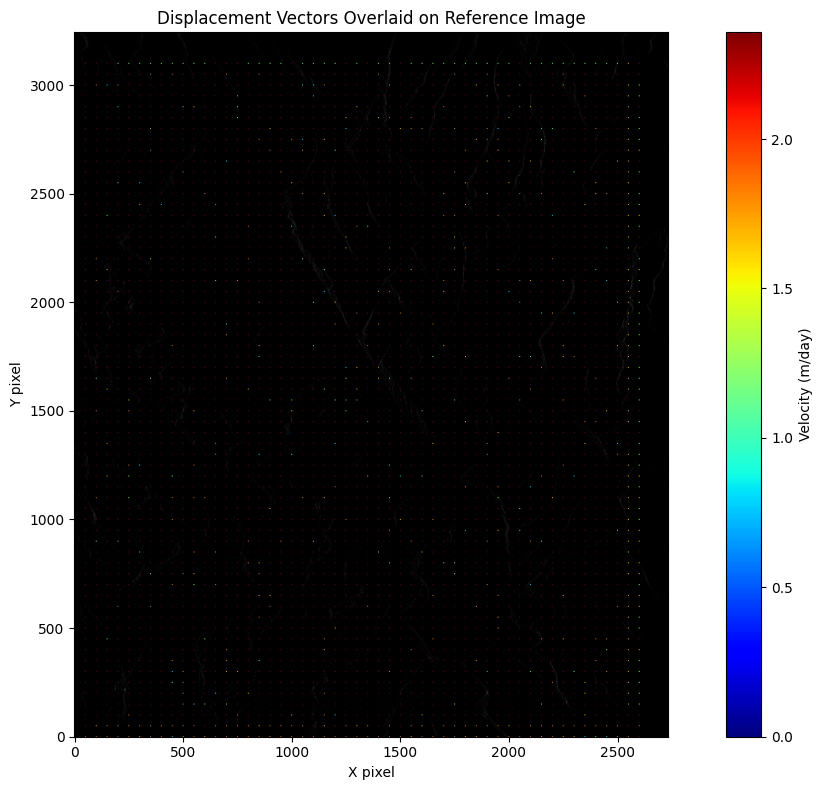

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(reference_img, cmap='gray')
plt.quiver(
    positions[:, 0], positions[:, 1],  # X, Y positions
    velocity[:, 0], velocity[:, 1],    # dx, dy vectors in meters/day
    magnitude,                         # color = speed
    angles='xy', scale_units='xy', scale=1, cmap='jet', width=0.002
)
plt.colorbar(label="Velocity (m/day)")
plt.title("Displacement Vectors Overlaid on Reference Image")
plt.xlabel("X pixel")
plt.ylabel("Y pixel")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


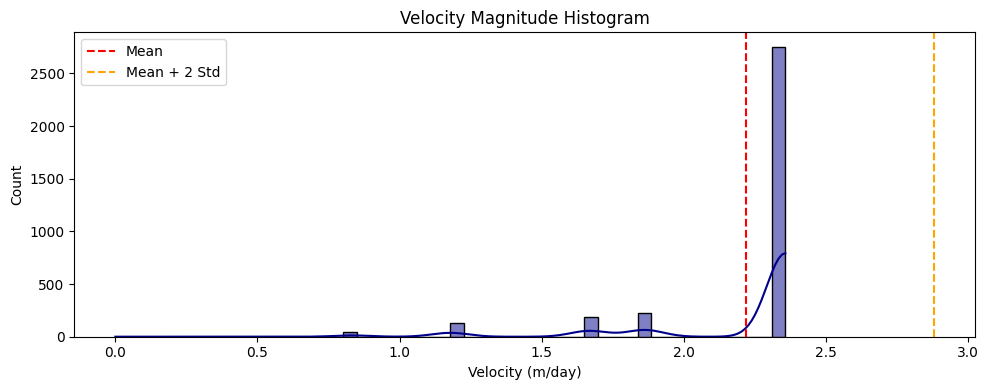

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(magnitude, bins=50, kde=True, color='darkblue')
plt.axvline(magnitude.mean(), color='red', linestyle='--', label='Mean')
plt.axvline(magnitude.mean() + 2*magnitude.std(), color='orange', linestyle='--', label='Mean + 2 Std')
plt.title("Velocity Magnitude Histogram")
plt.xlabel("Velocity (m/day)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
valid = magnitude < (magnitude.mean() + 2 * magnitude.std())
positions_valid = positions[valid]
velocity_valid = velocity[valid]

print(f"✅ Filtered {len(positions) - len(positions_valid)} outliers.")


✅ Filtered 0 outliers.


In [ ]:
import rasterio
import numpy as np

def load_tif(path):
    with rasterio.open(path) as src:
        return src.read(1).astype(np.float32), src.transform

ref_img, ref_transform = load_tif('/content/unzipped_output/.TIF DATA/REFERENCE_IMAGEl.tif')
sec_img, sec_transform = load_tif('/content/unzipped_output/.TIF DATA/SECONDARY_IMAGE.tif')


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
# Ensure both model and input tensors are on the same device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model (assuming AlexNet class is defined in a previous cell)
model = AlexNet()

# Load the state dictionary onto the model, mapping to the correct device
model.load_state_dict(torch.load('/content/drive/MyDrive/glacier_displacement_model.pth', map_location=DEVICE))

# Set the model to evaluation mode
model = model.to(DEVICE) # Ensure the model is on the correct device after loading the state_dict
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(2, 96, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1024, out_features=4096, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, 

In [ ]:
PATCH_SIZE = 100
STRIDE = 50

coords = [(x, y)
          for y in range(0, ref_img.shape[0] - PATCH_SIZE + 1, STRIDE)
          for x in range(0, ref_img.shape[1] - PATCH_SIZE + 1, STRIDE)]


In [ ]:
def normalize(patch):
    std = np.std(patch)
    return (patch - np.mean(patch)) / (std + 1e-5) if std > 1e-6 else np.zeros_like(patch)

SHIFT_RANGE = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

positions = []
displacements = []

with torch.no_grad():
    for (x, y) in coords:
        ref_patch = ref_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
        ref_patch = normalize(ref_patch)

        best_score = -np.inf
        best_shift = (0, 0)

        for dy in range(-SHIFT_RANGE, SHIFT_RANGE + 1):
            for dx in range(-SHIFT_RANGE, SHIFT_RANGE + 1):
                xs, ys = x + dx * STRIDE, y + dy * STRIDE
                if 0 <= xs <= sec_img.shape[1] - PATCH_SIZE and 0 <= ys <= sec_img.shape[0] - PATCH_SIZE:
                    sec_patch = sec_img[ys:ys+PATCH_SIZE, xs:xs+PATCH_SIZE]
                    sec_patch = normalize(sec_patch)
                else:
                    sec_patch = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)

                input_tensor = np.stack([ref_patch, sec_patch], axis=0)
                input_tensor = torch.tensor(input_tensor).unsqueeze(0).to(DEVICE)

                output = model(input_tensor)
                prob = torch.softmax(output, dim=1).squeeze()
                class_idx = torch.argmax(prob).item()
                score = prob[class_idx].item()

                if score > best_score:
                    best_score = score
                    best_shift = (dx, dy)

        positions.append((x, y))
        displacements.append(best_shift)

positions = np.array(positions)
displacements = np.array(displacements)


In [ ]:
range_spacing = 10  # meters per pixel
azimuth_spacing = 10
delta_days = 12  # from `first_line_time` difference

# Convert pixel shift to velocity (meters/day)
velocity_mps = displacements * np.array([range_spacing, azimuth_spacing]) / delta_days
magnitudes = np.linalg.norm(velocity_mps, axis=1)


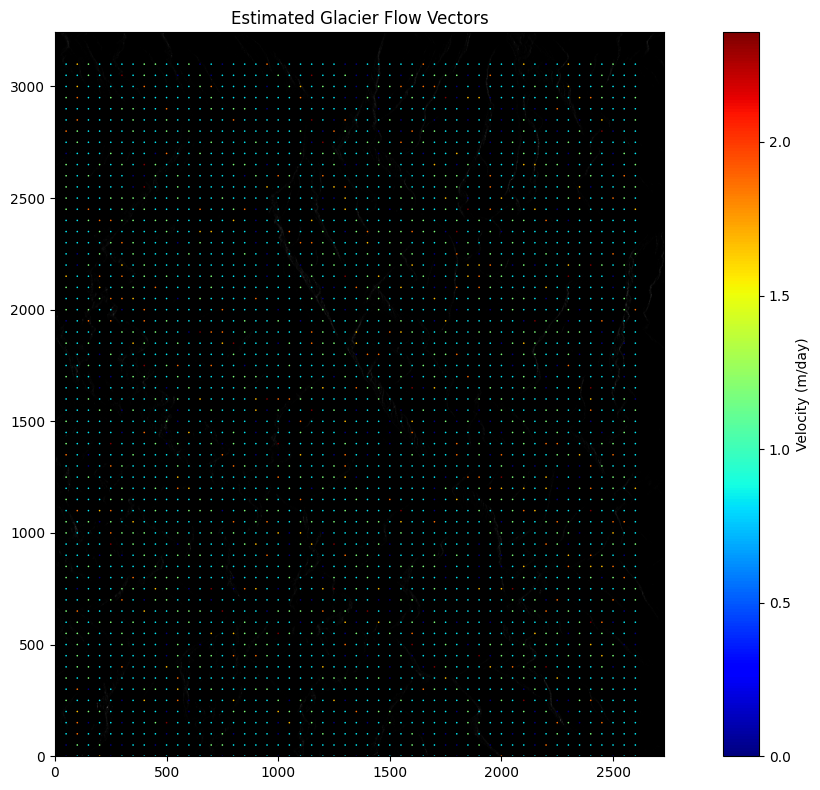

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(ref_img, cmap='gray')
plt.quiver(
    positions[:, 0], positions[:, 1],
    velocity_mps[:, 0], velocity_mps[:, 1],
    magnitudes, cmap='jet', angles='xy', scale_units='xy', scale=1, width=0.003
)
plt.colorbar(label="Velocity (m/day)")
plt.title("Estimated Glacier Flow Vectors")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
import rasterio

dem_path = "/content/unzipped_output/.TIF DATA/DEM_BASED_COREGISTERED_IMAGE.tif"

with rasterio.open(dem_path) as src:
    print(f"Band count: {src.count}")
    print(f"Shape: {src.height} x {src.width}")
    print(f"CRS: {src.crs}")
    print(f"Metadata: {src.meta}")

    for i in range(1, src.count + 1):
        band = src.read(i)
        print(f"Band {i} - min: {band.min()}, max: {band.max()}, mean: {band.mean():.2f}")


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Band count: 2
Shape: 3243 x 2731
CRS: EPSG:4326
Metadata: {'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 2731, 'height': 3243, 'count': 2, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(9.419765346763143e-05, 0.0, 0.0,
       0.0, -0.00010823330843123813, 0.0)}
Band 1 - min: 7.398443813144695e-08, max: 84.19306182861328, mean: 0.23
Band 2 - min: 0.0, max: 65.48634338378906, mean: 0.26


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
import rasterio

# Load ground truth displacement image
gt_path = '/content/unzipped_output/.TIF DATA/DEM_BASED_COREGISTERED_IMAGE.tif'
with rasterio.open(gt_path) as src:
    gt_dx = src.read(1)
    gt_dy = src.read(2)

# Convert to arrays
pred_dx = np.array([d[0] for d in displacements])
pred_dy = np.array([d[1] for d in displacements])
pos_x = np.array([p[0] for p in positions])
pos_y = np.array([p[1] for p in positions])

# Extract ground truth at model prediction positions
gt_dx_sampled = []
gt_dy_sampled = []
for x, y in zip(pos_x, pos_y):
    if 0 <= y < gt_dx.shape[0] and 0 <= x < gt_dx.shape[1]:
        gt_dx_sampled.append(gt_dx[int(y), int(x)])
        gt_dy_sampled.append(gt_dy[int(y), int(x)])
    else:
        gt_dx_sampled.append(0)
        gt_dy_sampled.append(0)

gt_dx_sampled = np.array(gt_dx_sampled)
gt_dy_sampled = np.array(gt_dy_sampled)

# Compute RMSE
rmse_dx = np.sqrt(mean_squared_error(gt_dx_sampled, pred_dx))
rmse_dy = np.sqrt(mean_squared_error(gt_dy_sampled, pred_dy))

# Compute MAE
mae_dx = mean_absolute_error(gt_dx_sampled, pred_dx)
mae_dy = mean_absolute_error(gt_dy_sampled, pred_dy)

print(f"✅ RMSE dx: {rmse_dx:.4f}, dy: {rmse_dy:.4f}")
print(f"✅ MAE  dx: {mae_dx:.4f}, dy: {mae_dy:.4f}")


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


✅ RMSE dx: 1.2403, dy: 1.2498
✅ MAE  dx: 0.9503, dy: 0.7435


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


✅ RMSE dx: 45.40 pixels | RMSE dy: 39.39 pixels
✅ MAE  dx: 37.01 pixels | MAE  dy: 25.01 pixels


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


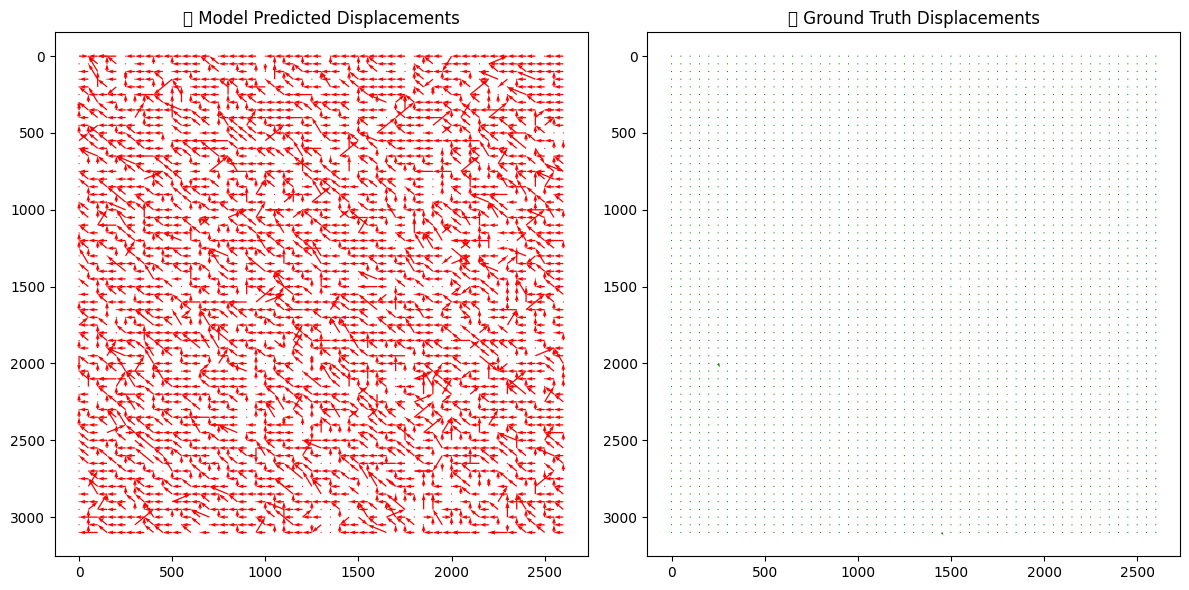

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1️⃣ Load Ground Truth Displacement Map
with rasterio.open('/content/unzipped_output/.TIF DATA/DEM_BASED_COREGISTERED_IMAGE.tif') as src:
    dem_flow = src.read()  # Shape: (2, H, W), assumed: Band 1 = dx, Band 2 = dy

# 2️⃣ Convert Model Predictions
positions = np.array(positions)     # [(x, y), ...] from your inference
pred_dx = np.array([d[0] for d in displacements]) * STRIDE
pred_dy = np.array([d[1] for d in displacements]) * STRIDE

# 3️⃣ Sample Ground Truth Displacements at Inference Coordinates
gt_dx = []
gt_dy = []

for x, y in positions:
    if (0 <= y < dem_flow.shape[1]) and (0 <= x < dem_flow.shape[2]):
        gt_dx.append(dem_flow[0, y, x])
        gt_dy.append(dem_flow[1, y, x])
    else:
        gt_dx.append(0)
        gt_dy.append(0)

gt_dx = np.array(gt_dx)
gt_dy = np.array(gt_dy)

# 4️⃣ Compute RMSE & MAE
rmse_dx = np.sqrt(np.mean((gt_dx - pred_dx)**2))
rmse_dy = np.sqrt(np.mean((gt_dy - pred_dy)**2))
mae_dx = np.mean(np.abs(gt_dx - pred_dx))
mae_dy = np.mean(np.abs(gt_dy - pred_dy))

print(f"✅ RMSE dx: {rmse_dx:.2f} pixels | RMSE dy: {rmse_dy:.2f} pixels")
print(f"✅ MAE  dx: {mae_dx:.2f} pixels | MAE  dy: {mae_dy:.2f} pixels")

# 5️⃣ Visual Comparison
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.quiver(positions[:, 0], positions[:, 1], pred_dx, pred_dy, color='r', angles='xy', scale_units='xy', scale=1)
plt.title("🔴 Model Predicted Displacements")
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
plt.quiver(positions[:, 0], positions[:, 1], gt_dx, gt_dy, color='g', angles='xy', scale_units='xy', scale=1)
plt.title("🟢 Ground Truth Displacements")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# 28/06/25

In [ ]:
import torchvision.transforms as T
from PIL import Image


In [ ]:
augmentation = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),            # small rotations
    T.ColorJitter(brightness=0.2, contrast=0.2),  # mild brightness/contrast
    T.ToTensor()
])


In [ ]:
import rasterio
import numpy as np

# Paths
ref_path = "/content/unzipped_output/.TIF DATA/REFERENCE_IMAGEl.tif"
sec_path = "/content/unzipped_output/.TIF DATA/SECONDARY_IMAGE.tif"
gt_path  = "/content/unzipped_output/.TIF DATA/DEM_BASED_COREGISTERED_IMAGE.tif"

# Load
with rasterio.open(ref_path) as src: reference_img = src.read(1).astype(np.float32)
with rasterio.open(sec_path) as src: secondary_img = src.read(1).astype(np.float32)
with rasterio.open(gt_path) as src:
    gt_dx = src.read(1).astype(np.float32)
    gt_dy = src.read(2).astype(np.float32)


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
print(reference_img.shape, secondary_img.shape, gt_dx.shape, gt_dy.shape)


(3243, 2731) (3243, 2731) (3243, 2731) (3243, 2731)


In [ ]:
PATCH_SIZE = 100
STRIDE = 50

coords = []
for y in range(0, reference_img.shape[0] - PATCH_SIZE + 1, STRIDE):
    for x in range(0, reference_img.shape[1] - PATCH_SIZE + 1, STRIDE):
        coords.append((x, y))


In [ ]:
import torch
from torch.utils.data import Dataset

def normalize(patch):
    std = np.std(patch)
    if std < 1e-6:
        return np.zeros_like(patch)
    return (patch - np.mean(patch)) / (std + 1e-5)

class GlacierRegressionDataset(Dataset):
    def __init__(self, ref, sec, gt_dx, gt_dy, coords):
        self.ref = ref
        self.sec = sec
        self.gt_dx = gt_dx
        self.gt_dy = gt_dy
        self.coords = coords

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        x, y = self.coords[idx]

        ref_patch = normalize(self.ref[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
        sec_patch = normalize(self.sec[y:y+PATCH_SIZE, x:x+PATCH_SIZE])

        input_tensor = np.stack([ref_patch, sec_patch], axis=0)

        # Ground truth shift at center pixel
        target_dx = self.gt_dx[y + PATCH_SIZE//2, x + PATCH_SIZE//2]
        target_dy = self.gt_dy[y + PATCH_SIZE//2, x + PATCH_SIZE//2]
        target = np.array([target_dx, target_dy], dtype=np.float32)

        return torch.tensor(input_tensor), torch.tensor(target)


In [ ]:
from torch.utils.data import DataLoader

dataset = GlacierRegressionDataset(reference_img, secondary_img, gt_dx, gt_dy, coords)
loader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)


In [ ]:
import torch.nn as nn

class ShiftRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(2, 32, 5, padding=2), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.cnn(x)
        return self.fc(x)


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ShiftRegressor().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

for epoch in range(30):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1:02d}, Loss: {avg_loss:.4f}")


Epoch 01, Loss: 0.5896
Epoch 02, Loss: 0.5821
Epoch 03, Loss: 0.5709
Epoch 04, Loss: 0.5591
Epoch 05, Loss: 0.5533
Epoch 06, Loss: 0.5512
Epoch 07, Loss: 0.5510
Epoch 08, Loss: 0.5490
Epoch 09, Loss: 0.5459
Epoch 10, Loss: 0.5471
Epoch 11, Loss: 0.5413
Epoch 12, Loss: 0.5653
Epoch 13, Loss: 0.5435
Epoch 14, Loss: 0.5374
Epoch 15, Loss: 0.5391
Epoch 16, Loss: 0.5342
Epoch 17, Loss: 0.5381
Epoch 18, Loss: 0.5328
Epoch 19, Loss: 0.5335
Epoch 20, Loss: 0.5311
Epoch 21, Loss: 0.5325
Epoch 22, Loss: 0.5288
Epoch 23, Loss: 0.5257
Epoch 24, Loss: 0.5326
Epoch 25, Loss: 0.5745
Epoch 26, Loss: 0.5293
Epoch 27, Loss: 0.5272
Epoch 28, Loss: 0.5179
Epoch 29, Loss: 0.5230
Epoch 30, Loss: 0.5222


In [ ]:
model.eval()
predicted_dx = []
predicted_dy = []
positions = []

with torch.no_grad():
    for x, y in coords:
        ref_patch = normalize(reference_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
        sec_patch = normalize(secondary_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE])
        input_tensor = np.stack([ref_patch, sec_patch], axis=0)
        input_tensor = torch.tensor(input_tensor).unsqueeze(0).to(DEVICE)

        output = model(input_tensor).cpu().numpy().flatten()
        predicted_dx.append(output[0])
        predicted_dy.append(output[1])
        positions.append((x, y))

predicted_dx = np.array(predicted_dx)
predicted_dy = np.array(predicted_dy)
positions = np.array(positions)


In [ ]:
from sklearn.metrics import mean_squared_error

gt_dx_samples = [gt_dx[y+PATCH_SIZE//2, x+PATCH_SIZE//2] for (x, y) in coords]
gt_dy_samples = [gt_dy[y+PATCH_SIZE//2, x+PATCH_SIZE//2] for (x, y) in coords]

rmse_dx = np.sqrt(mean_squared_error(gt_dx_samples, predicted_dx))
rmse_dy = np.sqrt(mean_squared_error(gt_dy_samples, predicted_dy))

print(f"✅ RMSE dx: {rmse_dx:.2f} | RMSE dy: {rmse_dy:.2f}")


✅ RMSE dx: 0.60 | RMSE dy: 0.83


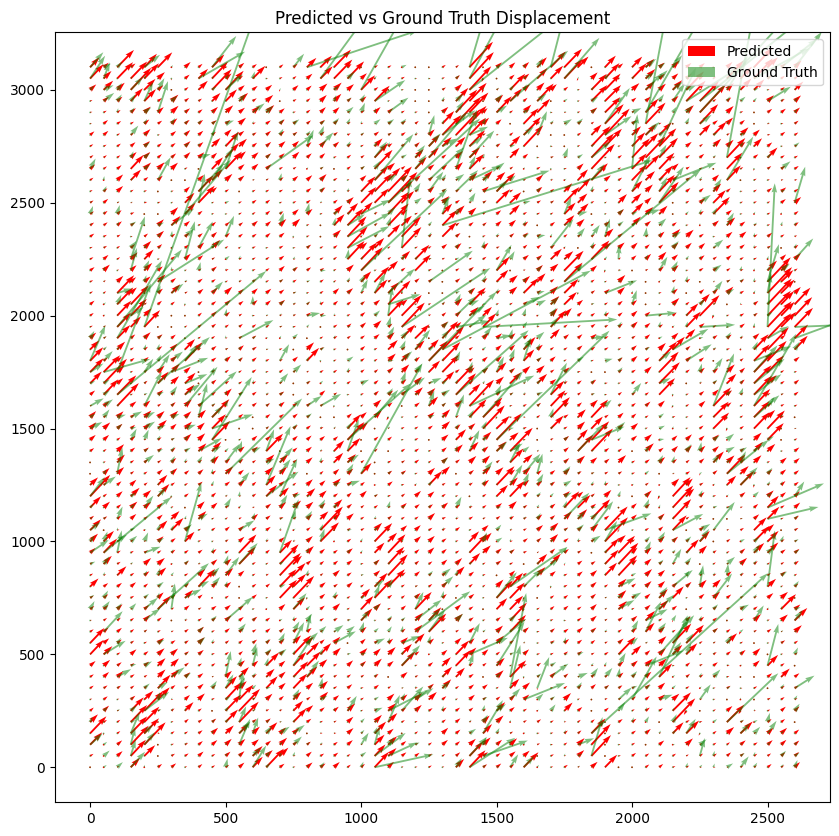

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.quiver(positions[:,0], positions[:,1], predicted_dx, predicted_dy, color='red', label='Predicted')
plt.quiver(positions[:,0], positions[:,1], gt_dx_samples, gt_dy_samples, color='green', alpha=0.5, label='Ground Truth')
plt.legend()
plt.title("Predicted vs Ground Truth Displacement")
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if downsample or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)

class SiameseEncoder(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()
        self.layer1 = nn.Conv2d(in_channels, 32, 3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.resblock1 = ResidualBlock(32, 64, downsample=True)
        self.resblock2 = ResidualBlock(64, 128, downsample=True)
        self.resblock3 = ResidualBlock(128, 256, downsample=True)
        self.resblock4 = ResidualBlock(256, 256, downsample=True)

    def forward(self, x):
        out = F.relu(self.bn1(self.layer1(x)))
        out = self.resblock1(out)
        out = self.resblock2(out)
        out = self.resblock3(out)
        out = self.resblock4(out)
        return out

class GlacierDisplacementRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        # Siamese twin encoders
        self.encoder = SiameseEncoder()
        # Fully connected regressor
        self.regressor = nn.Sequential(
            nn.Linear(256*7*7, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)  # dx, dy
        )

    def forward(self, x):
        # x shape: (batch, 2, H, W)
        ref = x[:, 0:1, :, :]
        sec = x[:, 1:2, :, :]

        feat_ref = self.encoder(ref)
        feat_sec = self.encoder(sec)

        # Difference feature (absolute)
        diff = torch.abs(feat_ref - feat_sec)
        diff_flat = diff.view(diff.size(0), -1)

        out = self.regressor(diff_flat)
        return out


In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GlacierDisplacementRegressor().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)


In [ ]:
for epoch in range(30):
    model.train()
    total_loss = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch:02d}, Loss: {avg_loss:.4f}")


Epoch 00, Loss: 0.5182
Epoch 01, Loss: 0.3708
Epoch 02, Loss: 0.2654
Epoch 03, Loss: 0.2010
Epoch 04, Loss: 0.2150
Epoch 05, Loss: 0.1350
Epoch 06, Loss: 0.1562
Epoch 07, Loss: 0.2042
Epoch 08, Loss: 0.1572
Epoch 09, Loss: 0.1558
Epoch 10, Loss: 0.1239


In [ ]:
def predict_displacement(model, ref_img, sec_img, x, y):
    # Crop 100x100 patches at (x, y)
    ref_patch = ref_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]
    sec_patch = sec_img[y:y+PATCH_SIZE, x:x+PATCH_SIZE]

    # Normalize
    ref_patch = normalize(ref_patch)
    sec_patch = normalize(sec_patch)

    # Stack to 2-channel
    input_tensor = np.stack([ref_patch, sec_patch], axis=0)
    input_tensor = torch.tensor(input_tensor, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    # Model prediction
    model.eval()
    with torch.no_grad():
        pred_shift = model(input_tensor)
        dx, dy = pred_shift.cpu().numpy()[0]

    return dx, dy


In [ ]:
test_x, test_y = coords[0]  # First patch location in grid

dx_pred, dy_pred = predict_displacement(model, reference_img, secondary_img, test_x, test_y)
print(f"Predicted shift at ({test_x},{test_y}): dx={dx_pred:.2f}, dy={dy_pred:.2f}")


Predicted shift at (0,0): dx=0.05, dy=0.05


In [ ]:
all_pred_dx = []
all_pred_dy = []

for (x, y) in coords:
    dx, dy = predict_displacement(model, reference_img, secondary_img, x, y)
    all_pred_dx.append(dx)
    all_pred_dy.append(dy)

all_pred_dx = np.array(all_pred_dx)
all_pred_dy = np.array(all_pred_dy)


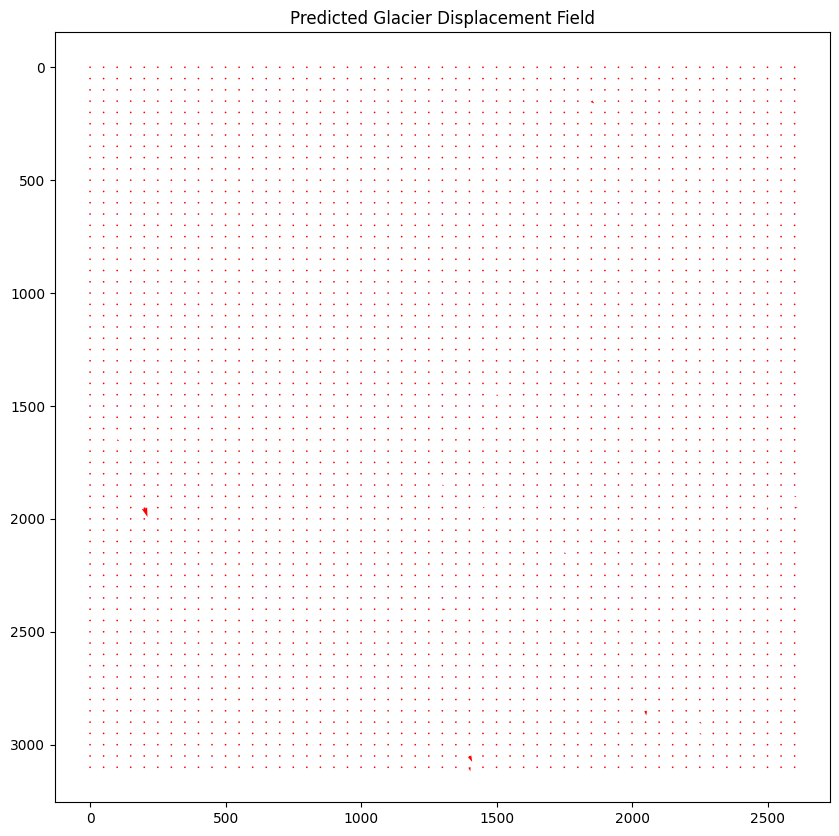

In [ ]:
plt.figure(figsize=(10, 10))
plt.quiver(
    [c[0] for c in coords],
    [c[1] for c in coords],
    all_pred_dx,
    all_pred_dy,
    color='red',
    angles='xy',
    scale_units='xy',
    scale=1
)
plt.gca().invert_yaxis()
plt.title("Predicted Glacier Displacement Field")
plt.show()


In [ ]:
with rasterio.open('/content/unzipped_output/.TIF DATA/DEM_BASED_COREGISTERED_IMAGE.tif') as src:
    gt_dx = src.read(1)  # Band 1
    gt_dy = src.read(2)  # Band 2


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
gt_dx_samples = []
gt_dy_samples = []

for (x, y) in coords:
    # Take DEM shift at the center of the patch
    center_x = x + PATCH_SIZE // 2
    center_y = y + PATCH_SIZE // 2

    if center_y < gt_dx.shape[0] and center_x < gt_dx.shape[1]:
        gt_dx_samples.append(gt_dx[center_y, center_x])
        gt_dy_samples.append(gt_dy[center_y, center_x])
    else:
        gt_dx_samples.append(0.0)
        gt_dy_samples.append(0.0)

gt_dx_samples = np.array(gt_dx_samples)
gt_dy_samples = np.array(gt_dy_samples)


In [ ]:
error_dx = all_pred_dx - gt_dx_samples
error_dy = all_pred_dy - gt_dy_samples

rmse_dx = np.sqrt(np.mean(error_dx ** 2))
rmse_dy = np.sqrt(np.mean(error_dy ** 2))
mae_dx = np.mean(np.abs(error_dx))
mae_dy = np.mean(np.abs(error_dy))

print(f"✅ RMSE dx: {rmse_dx:.2f} | RMSE dy: {rmse_dy:.2f}")
print(f"✅ MAE  dx: {mae_dx:.2f} | MAE  dy: {mae_dy:.2f}")


✅ RMSE dx: 0.16 | RMSE dy: 0.38
✅ MAE  dx: 0.07 | MAE  dy: 0.09


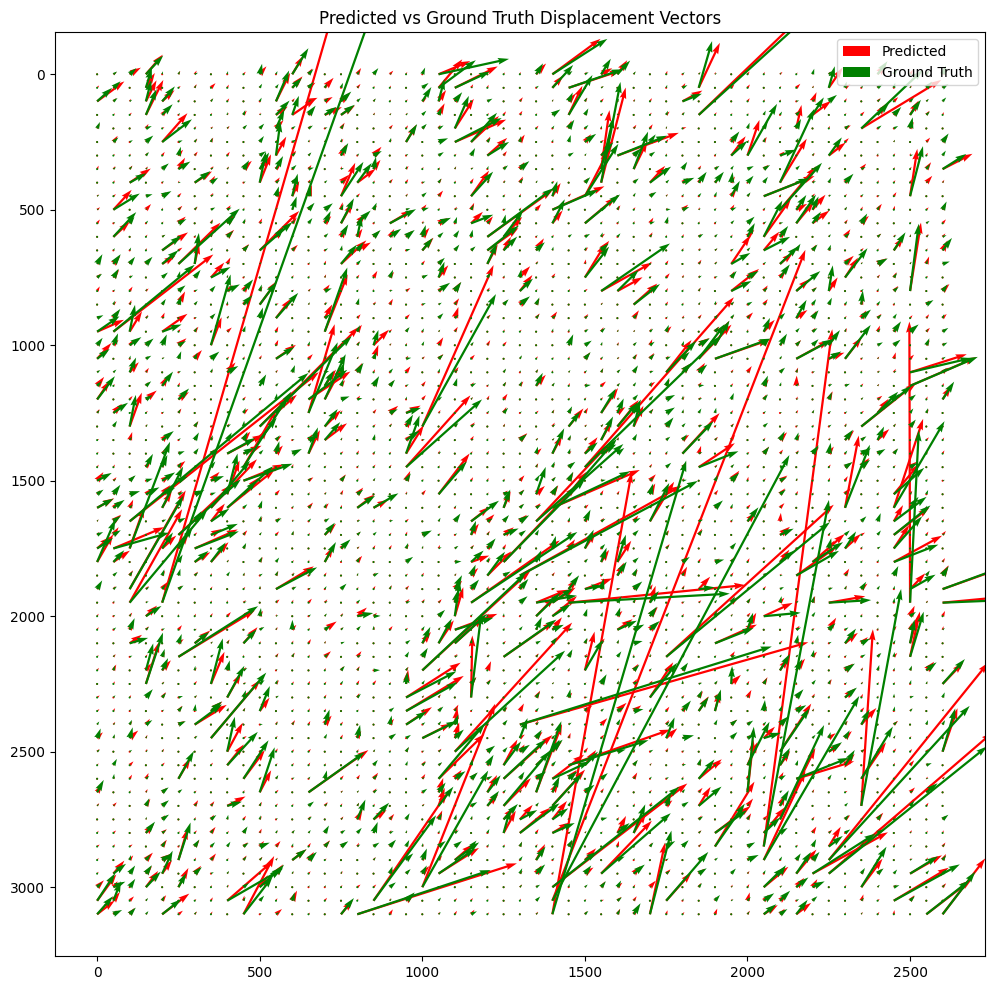

In [ ]:
plt.figure(figsize=(12, 12))
plt.quiver(
    [c[0] for c in coords],
    [c[1] for c in coords],
    all_pred_dx, all_pred_dy,
    color='red', label='Predicted'
)
plt.quiver(
    [c[0] for c in coords],
    [c[1] for c in coords],
    gt_dx_samples, gt_dy_samples,
    color='green', label='Ground Truth'
)
plt.gca().invert_yaxis()
plt.legend()
plt.title("Predicted vs Ground Truth Displacement Vectors")
plt.show()


In [ ]:
from torch.utils.data import random_split, DataLoader

# 1️⃣ Split into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

# 2️⃣ DataLoaders
BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=2)

print(f"✅ Train samples: {len(train_ds)}, Validation samples: {len(val_ds)}")

# 3️⃣ Training + Validation Loop with Accuracy
for epoch in range(30):
    # ========== Train Phase ==========
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE).float()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        # Accuracy (for regression: within threshold)
        diff = torch.abs(outputs - targets)
        correct = (diff < 0.5).all(dim=1).sum().item()
        train_correct += correct
        train_total += targets.size(0)

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ========== Validation Phase ==========
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE).float()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

            diff = torch.abs(outputs - targets)
            correct = (diff < 0.5).all(dim=1).sum().item()
            val_correct += correct
            val_total += targets.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")


✅ Train samples: 2671, Validation samples: 668


NameError: Caught NameError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/_utils/fetch.py", line 50, in fetch
    data = self.dataset.__getitems__(possibly_batched_index)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataset.py", line 420, in __getitems__
    return [self.dataset[self.indices[idx]] for idx in indices]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataset.py", line 420, in <listcomp>
    return [self.dataset[self.indices[idx]] for idx in indices]
            ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-

In [ ]:
print(f"Number of reference patches (coords): {len(coords)}")
print(f"NUM_CLASSES (shifts per patch): {NUM_CLASSES}")
print(f"Total dataset samples: {len(dataset)}")


Number of reference patches (coords): 3339


NameError: name 'NUM_CLASSES' is not defined

In [ ]:
SHIFT_RANGE = 2
NUM_CLASSES = (2 * SHIFT_RANGE + 1) ** 2

print(f"Number of reference patches (coords): {len(coords)}")
print(f"NUM_CLASSES (shifts per patch): {NUM_CLASSES}")
print(f"Total dataset samples: {len(dataset)}")


Number of reference patches (coords): 3339
NUM_CLASSES (shifts per patch): 25
Total dataset samples: 3339


# TEST